<a id='setup'></a>
## 1. Environment Setup & Reproducibility
We import core scientific, image processing, machine learning, and deep learning libraries. We enforce deterministic random seeds across Python, NumPy, and PyTorch to guarantee 100% experimental reproducibility.


In [1]:
import os
import sys
import glob
import time
import random
import warnings
from concurrent.futures import ThreadPoolExecutor

# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing & Computer Vision
import cv2
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops

# Machine learning & Evaluation
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Deep Learning with PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Style configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

# Set deterministic random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version: {torch.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"Execution Device: {device}")


PyTorch Version: 2.14.0+cpu
Scikit-Learn Version: 1.7.2
Execution Device: cpu


<a id='task1'></a>
---
## Task 1: Data Acquisition and Exploration

### 1.1 Dataset Discovery & Ingestion
The Chest X-Ray dataset is located in `data/chest_xray/`. It contains images organized across standard source partitions (`train`, `val`, and `test`) under two diagnostic classes:
- **`NORMAL`** (Class label `0`): Radiographically normal pediatric/adult chest scans.
- **`PNEUMONIA`** (Class label `1`): Confirmed cases of bacterial or viral pneumonia.

We dynamically traverse the dataset root, aggregate all instances into a unified tracking DataFrame, and verify complete data integrity.


In [2]:
# Resolve dataset path dynamically
possible_dirs = [
    os.path.join("data", "chest_xray"),
    os.path.join("..", "data", "chest_xray"),
    os.path.join(".", "chest_xray"),
    os.path.join("data")
]

data_dir = None
for candidate in possible_dirs:
    if os.path.exists(candidate) and any(os.path.exists(os.path.join(candidate, s)) for s in ['train', 'val', 'test']):
        data_dir = candidate
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate chest_xray directory. Please verify dataset location.")

print(f"[INFO] Using dataset directory: {os.path.abspath(data_dir)}")

# Discover all valid image paths
records = []
for split_folder in ['train', 'val', 'test']:
    for cls_name, cls_label in [('NORMAL', 0), ('PNEUMONIA', 1)]:
        folder_path = os.path.join(data_dir, split_folder, cls_name)
        if not os.path.exists(folder_path):
            continue
        for ext in ('*.jpeg', '*.jpg', '*.png'):
            for img_path in glob.glob(os.path.join(folder_path, ext)):
                records.append({
                    'filepath': img_path,
                    'filename': os.path.basename(img_path),
                    'source_split': split_folder,
                    'class_name': cls_name,
                    'label': cls_label
                })

df_meta = pd.DataFrame(records)
print(f"[INFO] Successfully cataloged {len(df_meta)} total chest radiographs.")
df_meta.head(10)


[INFO] Using dataset directory: C:\Users\usern\Desktop\CSET-343\Lab 6\data\chest_xray
[INFO] Successfully cataloged 5856 total chest radiographs.


,filepath,filename,source_split,class_name,label
0,data\chest_xray\train\NORMAL\IM-0115-0001.jpeg,IM-0115-0001.jpeg,train,NORMAL,0
1,data\chest_xray\train\NORMAL\IM-0117-0001.jpeg,IM-0117-0001.jpeg,train,NORMAL,0
2,data\chest_xray\train\NORMAL\IM-0119-0001.jpeg,IM-0119-0001.jpeg,train,NORMAL,0
3,data\chest_xray\train\NORMAL\IM-0122-0001.jpeg,IM-0122-0001.jpeg,train,NORMAL,0
4,data\chest_xray\train\NORMAL\IM-0125-0001.jpeg,IM-0125-0001.jpeg,train,NORMAL,0
5,data\chest_xray\train\NORMAL\IM-0127-0001.jpeg,IM-0127-0001.jpeg,train,NORMAL,0
6,data\chest_xray\train\NORMAL\IM-0128-0001.jpeg,IM-0128-0001.jpeg,train,NORMAL,0
7,data\chest_xray\train\NORMAL\IM-0129-0001.jpeg,IM-0129-0001.jpeg,train,NORMAL,0
8,data\chest_xray\train\NORMAL\IM-0131-0001.jpeg,IM-0131-0001.jpeg,train,NORMAL,0
9,data\chest_xray\train\NORMAL\IM-0133-0001.jpeg,IM-0133-0001.jpeg,train,NORMAL,0


### 1.2 Class Balance & Distribution Analysis
In healthcare diagnostics, examining class balance is critical. An imbalanced class distribution directly influences model training:
1. **Majority Class Bias**: Standard cross-entropy loss gradients can become dominated by the prevalent class.
2. **False Negatives vs False Positives**: In infectious diseases like pneumonia, failing to detect a true infection (**False Negative**) can result in fatal respiratory decompensation or systemic sepsis. Conversely, a **False Positive** leads to unnecessary empiric antibiotic therapy and potential adverse drug effects.

Let us quantify and visualize the exact class balance across the entire dataset.


             CHEST X-RAY DATASET CLASS BALANCE             
Diagnostic Class  Numeric Label  Image Count Percentage (%)
       PNEUMONIA              1         4273         72.97%
          NORMAL              0         1583         27.03%
------------------------------------------------------------
Total Dataset Instances: 5,856
Class Imbalance Ratio (Pneumonia : Normal): 2.70 : 1


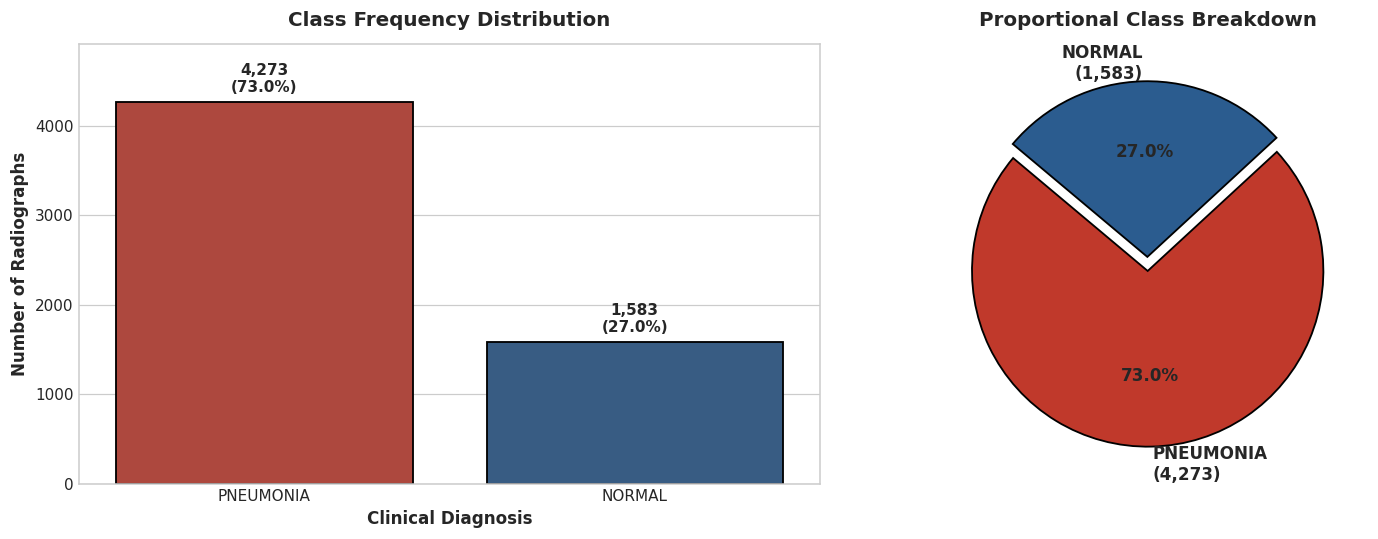

In [3]:
# Compute class counts and percentages
class_counts = df_meta['class_name'].value_counts()
class_pcts = df_meta['class_name'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Diagnostic Class': class_counts.index,
    'Numeric Label': [1 if c == 'PNEUMONIA' else 0 for c in class_counts.index],
    'Image Count': class_counts.values,
    'Percentage (%)': [f"{p:.2f}%" for p in class_pcts.values]
})

print("=" * 60)
print("             CHEST X-RAY DATASET CLASS BALANCE             ")
print("=" * 60)
print(summary_df.to_string(index=False))
print("-" * 60)
print(f"Total Dataset Instances: {len(df_meta):,}")
print(f"Class Imbalance Ratio (Pneumonia : Normal): {class_counts['PNEUMONIA']/class_counts['NORMAL']:.2f} : 1")
print("=" * 60)

# Dual Visualization: Count Bar Chart & Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Palette: Clinical Blue for Normal, Clinical Crimson for Pneumonia
palette = {'NORMAL': '#2b5c8f', 'PNEUMONIA': '#c0392b'}

# Bar plot
sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette, ax=axes[0], edgecolor='black', linewidth=1.2)
axes[0].set_title("Class Frequency Distribution", fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel("Clinical Diagnosis", fontsize=11, fontweight='semibold')
axes[0].set_ylabel("Number of Radiographs", fontsize=11, fontweight='semibold')
for i, (cnt, pct) in enumerate(zip(class_counts.values, class_pcts.values)):
    axes[0].text(i, cnt + 75, f"{cnt:,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(class_counts.values) * 1.15)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=[f"{c}\n({cnt:,})" for c, cnt in zip(class_counts.index, class_counts.values)],
    autopct='%1.1f%%',
    startangle=140,
    colors=[palette[c] for c in class_counts.index],
    explode=(0.04, 0.04),
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.2},
    textprops={'fontsize': 11, 'fontweight': 'semibold'}
)
axes[1].set_title("Proportional Class Breakdown", fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()


### 1.3 Radiographic Visual Inspection of Random Samples
We visualize **5 random Normal** and **5 random Pneumonia** chest radiographs from the dataset. 

#### Radiologic Differences to Observe:
- **Normal Chest Scans**: Crisp anatomical margins, well-aerated lung zones (radiolucent, appearing dark/black), sharply defined cardiac silhouettes, and clear bilateral costophrenic angles.
- **Pneumonia Scans**: Opacified consolidation regions (radiopaque, appearing white/cloudy), hazy lung margins due to fluid exudate, obscured diaphragm contours, and air bronchograms.


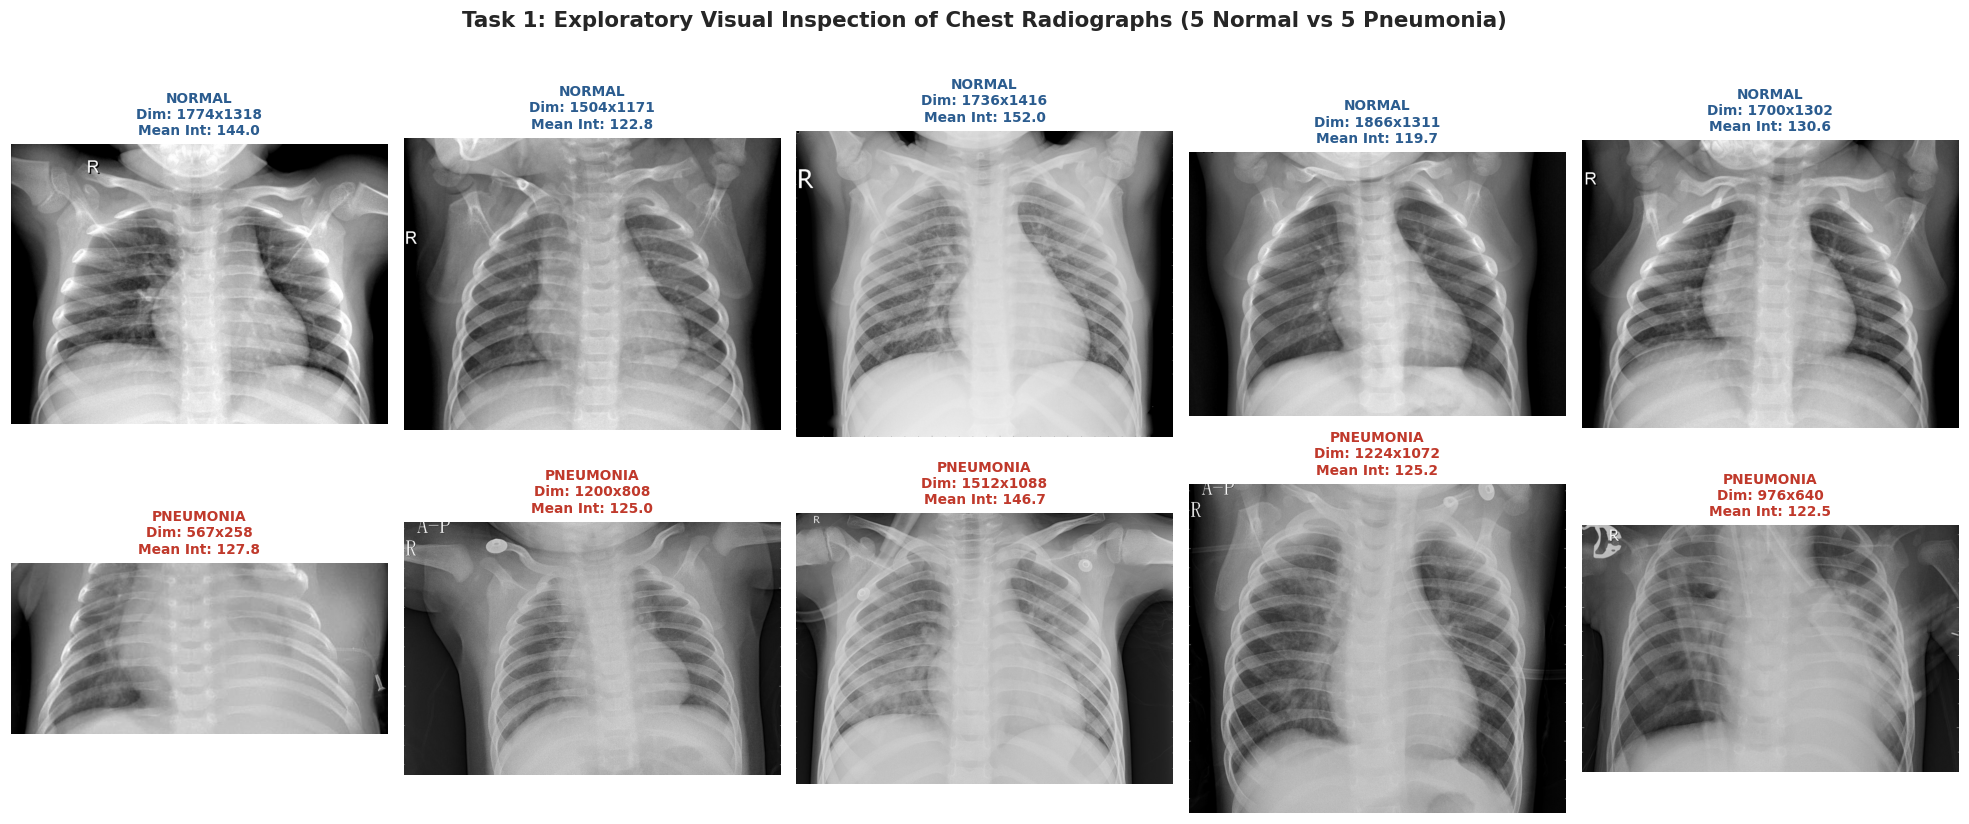

In [4]:
def display_sample_scans(df, num_per_class=5):
    fig, axes = plt.subplots(2, num_per_class, figsize=(18, 7.5))
    
    classes = [('NORMAL', 0, '#2b5c8f'), ('PNEUMONIA', 1, '#c0392b')]
    
    for row_idx, (cls_name, cls_label, color) in enumerate(classes):
        subset = df[df['class_name'] == cls_name].sample(num_per_class, random_state=SEED)
        for col_idx, (_, row) in enumerate(subset.iterrows()):
            ax = axes[row_idx, col_idx]
            img_bgr = cv2.imread(row['filepath'])
            if img_bgr is not None:
                img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
                orig_h, orig_w = img_gray.shape
                mean_int = np.mean(img_gray)
                ax.imshow(img_gray, cmap='gray')
                ax.set_title(f"{cls_name}\nDim: {orig_w}x{orig_h}\nMean Int: {mean_int:.1f}", 
                             fontsize=9, fontweight='bold', color=color)
            ax.axis('off')
            
    plt.suptitle("Task 1: Exploratory Visual Inspection of Chest Radiographs (5 Normal vs 5 Pneumonia)", 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

display_sample_scans(df_meta, num_per_class=5)


<a id='task2'></a>
---
## Task 2: Data Preprocessing & Handcrafted Feature Extraction





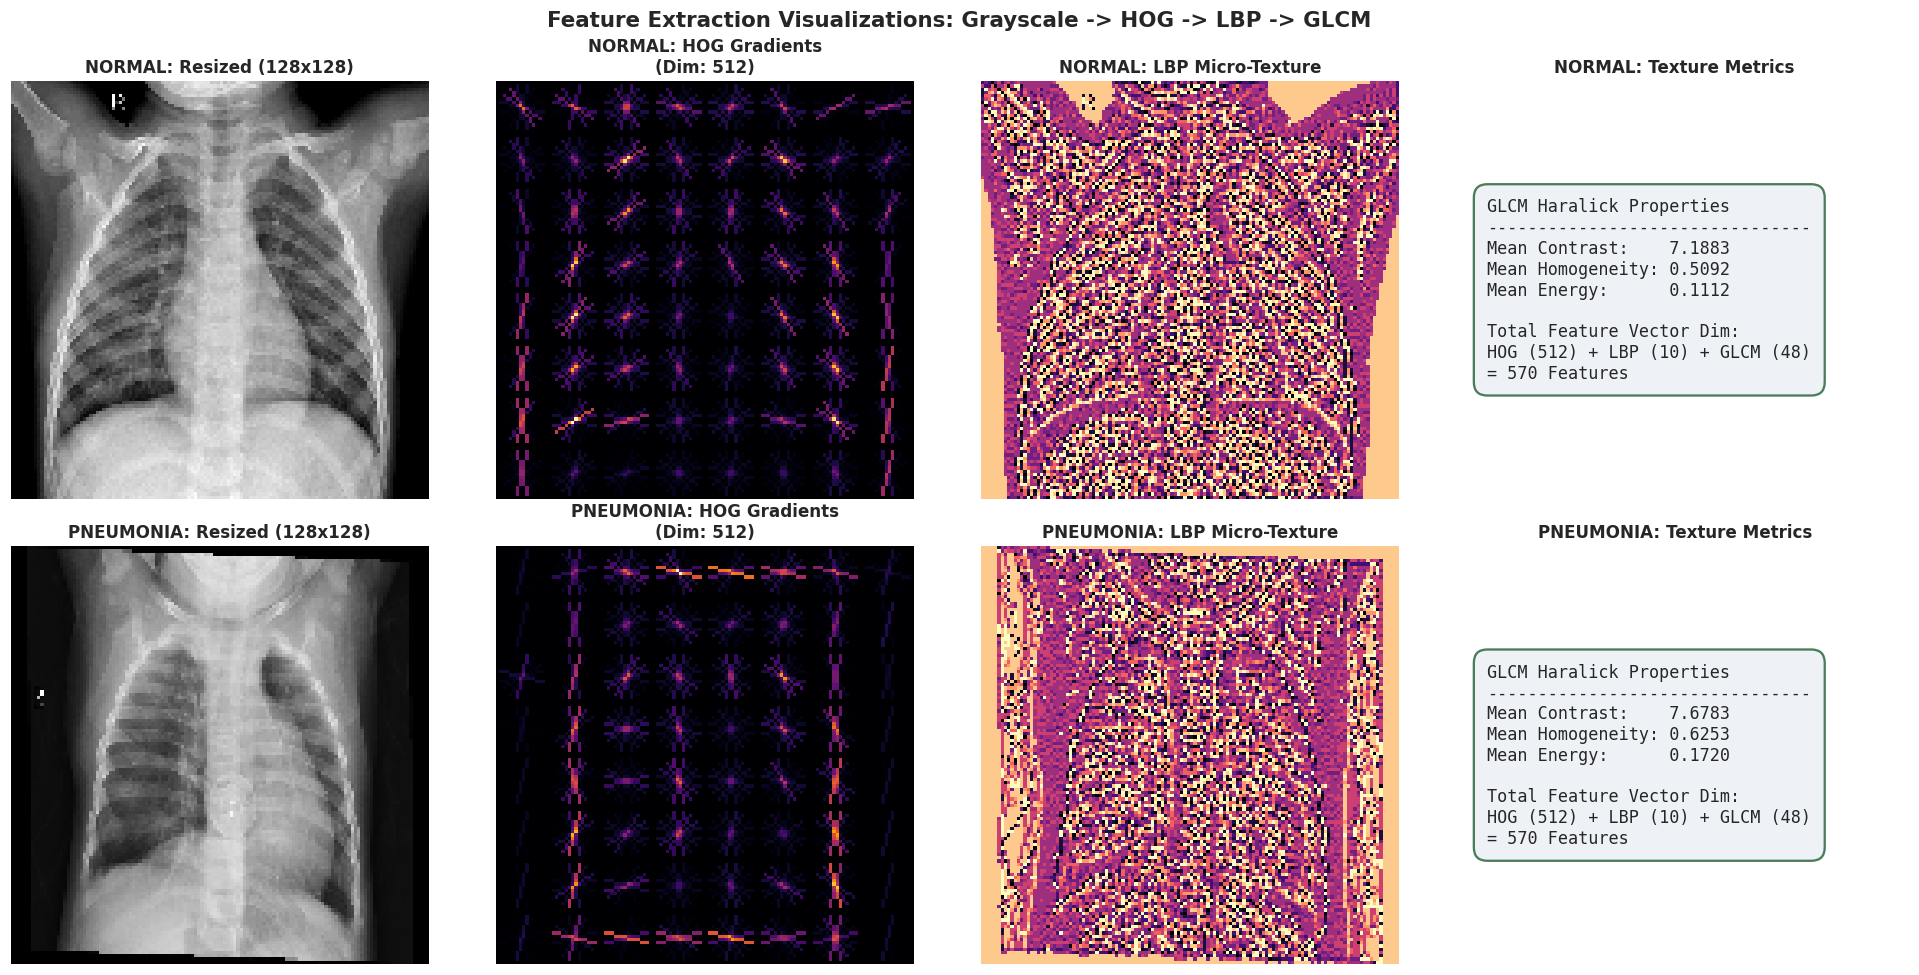

In [5]:
def demonstrate_feature_extraction(df):
    normal_sample = df[df['class_name'] == 'NORMAL'].iloc[10]['filepath']
    pneu_sample = df[df['class_name'] == 'PNEUMONIA'].iloc[10]['filepath']
    
    samples = [('NORMAL', normal_sample), ('PNEUMONIA', pneu_sample)]
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    
    for row_idx, (cls_name, path) in enumerate(samples):
        img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img_res = cv2.resize(img_gray, (128, 128))
        
        # 1. HOG Extraction & Visualization
        hog_feat, hog_vis = hog(
            img_res, orientations=8, pixels_per_cell=(16, 16),
            cells_per_block=(1, 1), visualize=True
        )
        
        # 2. LBP Extraction
        lbp = local_binary_pattern(img_res, P=8, R=1, method='uniform')
        
        # 3. GLCM Computation (quantized to 32 levels)
        img_q = (img_res // 8).astype(np.uint8)
        glcm = graycomatrix(img_q, distances=[1, 2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=32, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast').mean()
        homogeneity = graycoprops(glcm, 'homogeneity').mean()
        energy = graycoprops(glcm, 'energy').mean()
        
        # Plot Original
        axes[row_idx, 0].imshow(img_res, cmap='gray')
        axes[row_idx, 0].set_title(f"{cls_name}: Resized (128x128)", fontsize=11, fontweight='bold')
        axes[row_idx, 0].axis('off')
        
        # Plot HOG
        axes[row_idx, 1].imshow(hog_vis, cmap='inferno')
        axes[row_idx, 1].set_title(f"{cls_name}: HOG Gradients\n(Dim: {len(hog_feat)})", fontsize=11, fontweight='bold')
        axes[row_idx, 1].axis('off')
        
        # Plot LBP
        axes[row_idx, 2].imshow(lbp, cmap='magma')
        axes[row_idx, 2].set_title(f"{cls_name}: LBP Micro-Texture", fontsize=11, fontweight='bold')
        axes[row_idx, 2].axis('off')
        
        # Plot GLCM Summary Card
        axes[row_idx, 3].axis('off')
        summary_text = (
            f"GLCM Haralick Properties\n"
            f"--------------------------------\n"
            f"Mean Contrast:    {contrast:.4f}\n"
            f"Mean Homogeneity: {homogeneity:.4f}\n"
            f"Mean Energy:      {energy:.4f}\n\n"
            f"Total Feature Vector Dim:\n"
            f"HOG (512) + LBP (10) + GLCM (48)\n"
            f"= 570 Features"
        )
        axes[row_idx, 3].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
                              bbox=dict(boxstyle='round,pad=0.8', facecolor='#eef2f7', edgecolor='#4a7c59', linewidth=1.5),
                              verticalalignment='center')
        axes[row_idx, 3].set_title(f"{cls_name}: Texture Metrics", fontsize=11, fontweight='bold')

    plt.suptitle("Feature Extraction Visualizations: Grayscale -> HOG -> LBP -> GLCM", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

demonstrate_feature_extraction(df_meta)


### Multithreaded Feature Vectorization & Image Caching



In [6]:
def extract_features_single(item):
    filepath, label = item
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None, None
    img_res = cv2.resize(img, (128, 128))
    
    # 1. HOG
    h = hog(img_res, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1), visualize=False)
    
    # 2. LBP
    lbp = local_binary_pattern(img_res, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
    
    # 3. GLCM (32 intensity levels for optimal efficiency and noise tolerance)
    img_q = (img_res // 8).astype(np.uint8)
    glcm = graycomatrix(img_q, distances=[1, 2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=32, symmetric=True, normed=True)
    glcm_props = np.hstack([
        graycoprops(glcm, p).ravel() for p in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    ])
    
    # Concatenated Handcrafted Feature Vector: 512 + 10 + 48 = 570
    feature_vec = np.hstack([h, lbp_hist, glcm_props]).astype(np.float32)
    img_norm = (img_res.astype(np.float32) / 255.0)[np.newaxis, :, :]  # Shape: (1, 128, 128)
    
    return img_norm, feature_vec, label

print(f"[INFO] Beginning multithreaded preprocessing of {len(df_meta)} images...")
t_start = time.time()

items = list(zip(df_meta['filepath'].values, df_meta['label'].values))

with ThreadPoolExecutor(max_workers=os.cpu_count() or 8) as executor:
    processed_results = list(executor.map(extract_features_single, items))

valid_results = [r for r in processed_results if r[0] is not None]
X_images = np.stack([r[0] for r in valid_results])
X_features = np.stack([r[1] for r in valid_results])
y_labels = np.array([r[2] for r in valid_results], dtype=np.int64)

elapsed_sec = time.time() - t_start
print(f"[SUCCESS] Processed {len(X_images)} radiographs in {elapsed_sec:.2f} seconds!")
print(f" - Raw Images Tensor Shape:        {X_images.shape} (N, Channels, H, W)")
print(f" - Handcrafted Feature Matrix:     {X_features.shape} (N, Features)")
print(f" - Class Labels Vector:            {y_labels.shape}")


[INFO] Beginning multithreaded preprocessing of 5856 images...


[SUCCESS] Processed 5856 radiographs in 28.70 seconds!
 - Raw Images Tensor Shape:        (5856, 1, 128, 128) (N, Channels, H, W)
 - Handcrafted Feature Matrix:     (5856, 570) (N, Features)
 - Class Labels Vector:            (5856,)


### Stratified Dataset Partitioning (70% Train, 15% Validation, 15% Test)
The lab specification mandates:
- **Training Set**: $70\%$
- **Validation Set**: $15\%$
- **Testing Set**: $15\%$

To prevent sampling distortion given the underlying class imbalance, we employ **Stratified Splitting**. This guarantees that the proportion of Normal ($27.03\%$) to Pneumonia ($72.97\%$) remains identical across all three subsets.


In [7]:
# Step 1: Split into 70% Train and 30% Temp (Val + Test)
indices = np.arange(len(y_labels))
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=SEED, stratify=y_labels
)

# Step 2: Split 30% Temp equally into 15% Validation and 15% Test
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED, stratify=y_labels[temp_idx]
)

# Slice Feature Matrices and Image Tensors
X_feat_train, y_train = X_features[train_idx], y_labels[train_idx]
X_feat_val, y_val = X_features[val_idx], y_labels[val_idx]
X_feat_test, y_test = X_features[test_idx], y_labels[test_idx]

X_img_train = X_images[train_idx]
X_img_val = X_images[val_idx]
X_img_test = X_images[test_idx]

# Feature Scaling (Crucial for SVM and Logistic Regression)
scaler = StandardScaler()
X_feat_train_scaled = scaler.fit_transform(X_feat_train)
X_feat_val_scaled = scaler.transform(X_feat_val)
X_feat_test_scaled = scaler.transform(X_feat_test)

# Verify Split Integrity
split_summary = pd.DataFrame([
    {
        'Split Partition': 'Training (70%)',
        'Total Samples': len(train_idx),
        'Normal (Count / %)': f"{np.sum(y_train == 0):,} ({np.mean(y_train == 0)*100:.2f}%)",
        'Pneumonia (Count / %)': f"{np.sum(y_train == 1):,} ({np.mean(y_train == 1)*100:.2f}%)"
    },
    {
        'Split Partition': 'Validation (15%)',
        'Total Samples': len(val_idx),
        'Normal (Count / %)': f"{np.sum(y_val == 0):,} ({np.mean(y_val == 0)*100:.2f}%)",
        'Pneumonia (Count / %)': f"{np.sum(y_val == 1):,} ({np.mean(y_val == 1)*100:.2f}%)"
    },
    {
        'Split Partition': 'Testing (15%)',
        'Total Samples': len(test_idx),
        'Normal (Count / %)': f"{np.sum(y_test == 0):,} ({np.mean(y_test == 0)*100:.2f}%)",
        'Pneumonia (Count / %)': f"{np.sum(y_test == 1):,} ({np.mean(y_test == 1)*100:.2f}%)"
    }
])

print("=" * 75)
print("              STRATIFIED DATA SPLIT VERIFICATION TABLE             ")
print("=" * 75)
print(split_summary.to_string(index=False))
print("=" * 75)


              STRATIFIED DATA SPLIT VERIFICATION TABLE             
 Split Partition  Total Samples Normal (Count / %) Pneumonia (Count / %)
  Training (70%)           4099     1,108 (27.03%)        2,991 (72.97%)
Validation (15%)            878       237 (26.99%)          641 (73.01%)
   Testing (15%)            879       238 (27.08%)          641 (72.92%)


<a id='task3'></a>
---
## Task 3: Model Training, Cross-Validation & Hyperparameter Tuning




In [8]:
print("[INFO] Evaluating Baseline Classifiers using 5-Fold Stratified Cross-Validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models_classical = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
    'Random Forest (100 Trees)': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=SEED, n_jobs=-1),
    'SVM (RBF Kernel)': SVC(kernel='rbf', C=2.0, gamma='scale', probability=True, random_state=SEED)
}

cv_results = {}
for name, clf in models_classical.items():
    t0 = time.time()
    scores = cross_val_score(clf, X_feat_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    duration = time.time() - t0
    cv_results[name] = scores
    print(f" -> {name:25s} | 5-Fold Mean Accuracy: {scores.mean()*100:.2f}% (±{scores.std()*100:.2f}%) | Time: {duration:.2f}s")

# Fit models on full training partition
fitted_classical = {}
for name, clf in models_classical.items():
    clf.fit(X_feat_train_scaled, y_train)
    fitted_classical[name] = clf
print("[INFO] All classical baseline classifiers fitted on training set.")


[INFO] Evaluating Baseline Classifiers using 5-Fold Stratified Cross-Validation...


 -> Logistic Regression       | 5-Fold Mean Accuracy: 93.34% (±0.48%) | Time: 5.55s


 -> Random Forest (100 Trees) | 5-Fold Mean Accuracy: 92.92% (±0.62%) | Time: 5.81s


 -> SVM (RBF Kernel)          | 5-Fold Mean Accuracy: 95.58% (±0.60%) | Time: 10.22s


[INFO] All classical baseline classifiers fitted on training set.


### Deep Learning Baseline: Convolutional Neural Network (CNN)



In [9]:
class ChestXRayCNN(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 64x64
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 32x32
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 16x16
            
            # Spatial dimension standardization
            nn.AdaptiveAvgPool2d((4, 4))
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate * 0.75),
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        feat = self.features(x)
        feat_flat = torch.flatten(feat, 1)
        out = self.classifier(feat_flat)
        return out

# Convert NumPy arrays to PyTorch Datasets
train_ds = TensorDataset(torch.from_numpy(X_img_train), torch.from_numpy(y_train).float().unsqueeze(1))
val_ds = TensorDataset(torch.from_numpy(X_img_val), torch.from_numpy(y_val).float().unsqueeze(1))
test_ds = TensorDataset(torch.from_numpy(X_img_test), torch.from_numpy(y_test).float().unsqueeze(1))

# Batch loaders
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f"[INFO] DataLoaders prepared: Train batches={len(train_loader)}, Val batches={len(val_loader)}, Test batches={len(test_loader)}")


[INFO] DataLoaders prepared: Train batches=65, Val batches=14, Test batches=14


###  CNN Hyperparameter Tuning & Model Training



In [10]:
def train_evaluate_cnn(config_name, lr=1e-3, weight_decay=0.0, dropout=0.3, epochs=8):
    print(f"\n{'='*70}\n[TRAINING] Starting {config_name} (LR: {lr}, Weight Decay: {weight_decay}, Dropout: {dropout})\n{'='*70}")
    
    torch.manual_seed(SEED)
    model = ChestXRayCNN(dropout_rate=dropout).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_weights = None
    
    for epoch in range(1, epochs + 1):
        # Training Phase
        model.train()
        running_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch_x.size(0)
            
        train_loss = running_loss / len(train_ds)
        
        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                loss = criterion(logits, batch_y)
                val_loss += loss.item() * batch_x.size(0)
                probs = torch.sigmoid(logits).cpu().numpy()
                val_preds.extend((probs >= 0.5).astype(int).ravel())
                val_targets.extend(batch_y.cpu().numpy().astype(int).ravel())
                
        val_loss /= len(val_ds)
        val_acc = accuracy_score(val_targets, val_preds)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict().copy()
            
        print(f"Epoch {epoch:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc*100:.2f}%")
        
    model.load_state_dict(best_weights)
    return model, history

# Train Baseline CNN
model_baseline_cnn, history_baseline = train_evaluate_cnn(
    "Baseline CNN", lr=1e-3, weight_decay=0.0, dropout=0.3, epochs=8
)

# Train Tuned CNN
model_tuned_cnn, history_tuned = train_evaluate_cnn(
    "Tuned CNN", lr=5e-4, weight_decay=1e-4, dropout=0.4, epochs=8
)



[TRAINING] Starting Baseline CNN (LR: 0.001, Weight Decay: 0.0, Dropout: 0.3)


Epoch 01/08 | Train Loss: 0.2762 | Val Loss: 0.5431 | Val Accuracy: 74.37%


Epoch 02/08 | Train Loss: 0.1531 | Val Loss: 0.2598 | Val Accuracy: 89.86%


Epoch 03/08 | Train Loss: 0.1438 | Val Loss: 0.1483 | Val Accuracy: 94.87%


Epoch 04/08 | Train Loss: 0.1371 | Val Loss: 0.1424 | Val Accuracy: 95.44%


...

Epoch 04/08 | Train Loss: 0.1459 | Val Loss: 0.1755 | Val Accuracy: 93.28%


Epoch 05/08 | Train Loss: 0.1426 | Val Loss: 0.1307 | Val Accuracy: 94.99%


Epoch 06/08 | Train Loss: 0.1180 | Val Loss: 0.1247 | Val Accuracy: 94.87%


Epoch 07/08 | Train Loss: 0.1257 | Val Loss: 0.1591 | Val Accuracy: 94.99%


Epoch 08/08 | Train Loss: 0.1239 | Val Loss: 0.2838 | Val Accuracy: 88.61%


### 3.5 CNN Training Diagnostics & Learning Curves
Plotting loss and accuracy curves provides critical diagnostic insight into convergence dynamics, bias-variance tradeoff, and overfitting risks.


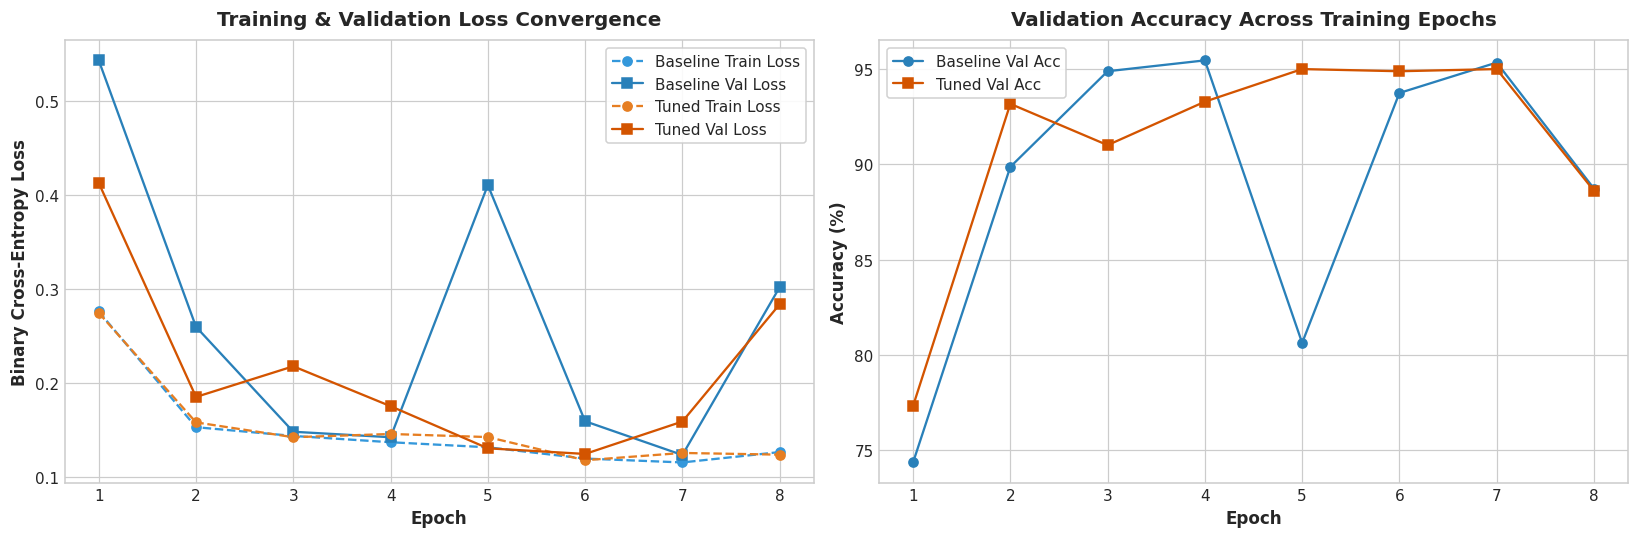

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = range(1, 9)

# Loss Plot
axes[0].plot(epochs_range, history_baseline['train_loss'], 'o--', color='#3498db', label='Baseline Train Loss')
axes[0].plot(epochs_range, history_baseline['val_loss'], 's-', color='#2980b9', label='Baseline Val Loss')
axes[0].plot(epochs_range, history_tuned['train_loss'], 'o--', color='#e67e22', label='Tuned Train Loss')
axes[0].plot(epochs_range, history_tuned['val_loss'], 's-', color='#d35400', label='Tuned Val Loss')
axes[0].set_title("Training & Validation Loss Convergence", fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel("Epoch", fontsize=11, fontweight='semibold')
axes[0].set_ylabel("Binary Cross-Entropy Loss", fontsize=11, fontweight='semibold')
axes[0].legend(frameon=True, facecolor='white', framealpha=0.9)

# Accuracy Plot
axes[1].plot(epochs_range, [acc*100 for acc in history_baseline['val_acc']], 'o-', color='#2980b9', label='Baseline Val Acc')
axes[1].plot(epochs_range, [acc*100 for acc in history_tuned['val_acc']], 's-', color='#d35400', label='Tuned Val Acc')
axes[1].set_title("Validation Accuracy Across Training Epochs", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("Epoch", fontsize=11, fontweight='semibold')
axes[1].set_ylabel("Accuracy (%)", fontsize=11, fontweight='semibold')
axes[1].legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()


<a id='task4'></a>
---
## Task 4: Comprehensive Model Evaluation & Diagnostic Comparisons

### 4.1 Multi-Metric Quantitative Evaluation on Independent Test Set (15%)
We evaluate all developed models on the untouched test partition ($N = 879$ radiographs). 

#### Clinically Essential Metrics:
- **Accuracy**: Overall fraction of correct classifications $\frac{TP+TN}{TP+TN+FP+FN}$.
- **Precision (Positive Predictive Value)**: $\frac{TP}{TP+FP}$. Reflects antibiotic stewardship (avoiding unneeded therapy).
- **Recall (Sensitivity)**: $\frac{TP}{TP+FN}$. **The most critical metric in clinical screening**, measuring the system's ability to catch true infections without fatal misses.
- **F1-Score**: Harmonic mean of Precision and Recall: $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$.
- **AUROC (Area Under the Receiver Operating Characteristic Curve)**: Discrimination capacity across all possible diagnostic operating thresholds.


In [12]:
def evaluate_pytorch_model(model, loader):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch_x, _ in loader:
            batch_x = batch_x.to(device)
            logits = model(batch_x)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            all_probs.extend(probs)
    all_probs = np.array(all_probs)
    preds = (all_probs >= 0.5).astype(int)
    return preds, all_probs

# Predictions from Classical Models
eval_results = {}
for name, clf in fitted_classical.items():
    preds = clf.predict(X_feat_test_scaled)
    probs = clf.predict_proba(X_feat_test_scaled)[:, 1]
    eval_results[name] = (preds, probs)

# Predictions from CNNs
preds_base, probs_base = evaluate_pytorch_model(model_baseline_cnn, test_loader)
eval_results['Baseline CNN'] = (preds_base, probs_base)

preds_tuned, probs_tuned = evaluate_pytorch_model(model_tuned_cnn, test_loader)
eval_results['Tuned CNN'] = (preds_tuned, probs_tuned)

# Tabulate Metrics
metrics_list = []
for name, (preds, probs) in eval_results.items():
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    metrics_list.append({
        'Model Architecture': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall (Sensitivity)': rec,
        'F1-Score': f1,
        'AUROC': auc
    })

df_metrics = pd.DataFrame(metrics_list).sort_values(by='AUROC', ascending=False).reset_index(drop=True)

# Formatted Display Table
df_display = df_metrics.copy()
for col in ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score', 'AUROC']:
    df_display[col] = df_display[col].apply(lambda v: f"{v*100:.2f}%" if col != 'AUROC' else f"{v:.4f}")

print("=" * 88)
print("             INDEPENDENT TEST SET (15%) CLASSIFIER BENCHMARK SUMMARY             ")
print("=" * 88)
print(df_display.to_string(index=False))
print("=" * 88)


             INDEPENDENT TEST SET (15%) CLASSIFIER BENCHMARK SUMMARY             
       Model Architecture Accuracy Precision Recall (Sensitivity) F1-Score  AUROC
             Baseline CNN   88.40%    99.63%               84.40%   91.39% 0.9884
                Tuned CNN   89.87%    99.64%               86.43%   92.56% 0.9883
         SVM (RBF Kernel)   94.54%    95.97%               96.57%   96.27% 0.9818
Random Forest (100 Trees)   92.72%    94.18%               95.94%   95.05% 0.9737
      Logistic Regression   92.61%    95.43%               94.38%   94.90% 0.9722


### 4.2 Receiver Operating Characteristic (ROC) & AUROC Curve Analysis
The ROC curve plots the **True Positive Rate (Sensitivity)** against the **False Positive Rate ($1 - \text{Specificity}$)** across the entire continuum of classification decision thresholds.
An ideal diagnostic test reaches the upper left corner $(\text{AUROC} = 1.0)$.


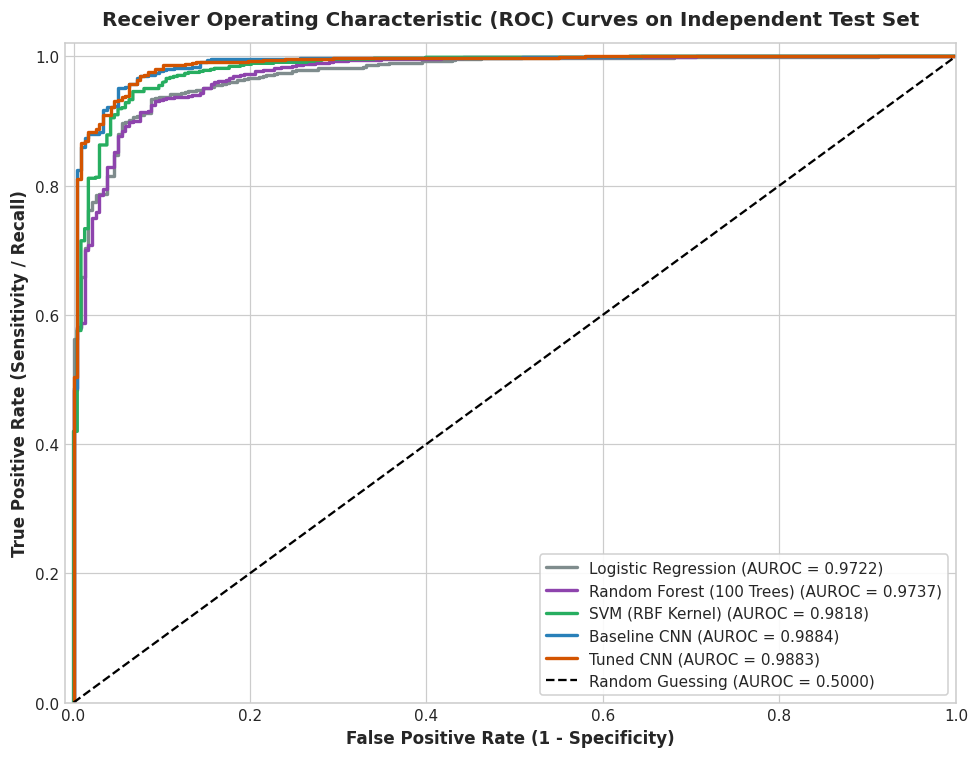

In [13]:
plt.figure(figsize=(9, 7))

colors_map = {
    'Tuned CNN': '#d35400',
    'Baseline CNN': '#2980b9',
    'SVM (RBF Kernel)': '#27ae60',
    'Random Forest (100 Trees)': '#8e44ad',
    'Logistic Regression': '#7f8c8d'
}

for name, (preds, probs) in eval_results.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUROC = {auc:.4f})", 
             color=colors_map.get(name, '#333333'), linewidth=2.2)

plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing (AUROC = 0.5000)", linewidth=1.5)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11, fontweight='semibold')
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11, fontweight='semibold')
plt.title("Receiver Operating Characteristic (ROC) Curves on Independent Test Set", fontsize=13, fontweight='bold', pad=12)
plt.legend(loc="lower right", frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.show()


### 4.3 Confusion Matrix Analysis
We construct side-by-side Confusion Matrices for our two leading architectures:
1. **Best Deep Learning Model**: Tuned CNN
2. **Best Classical Model**: SVM (RBF)


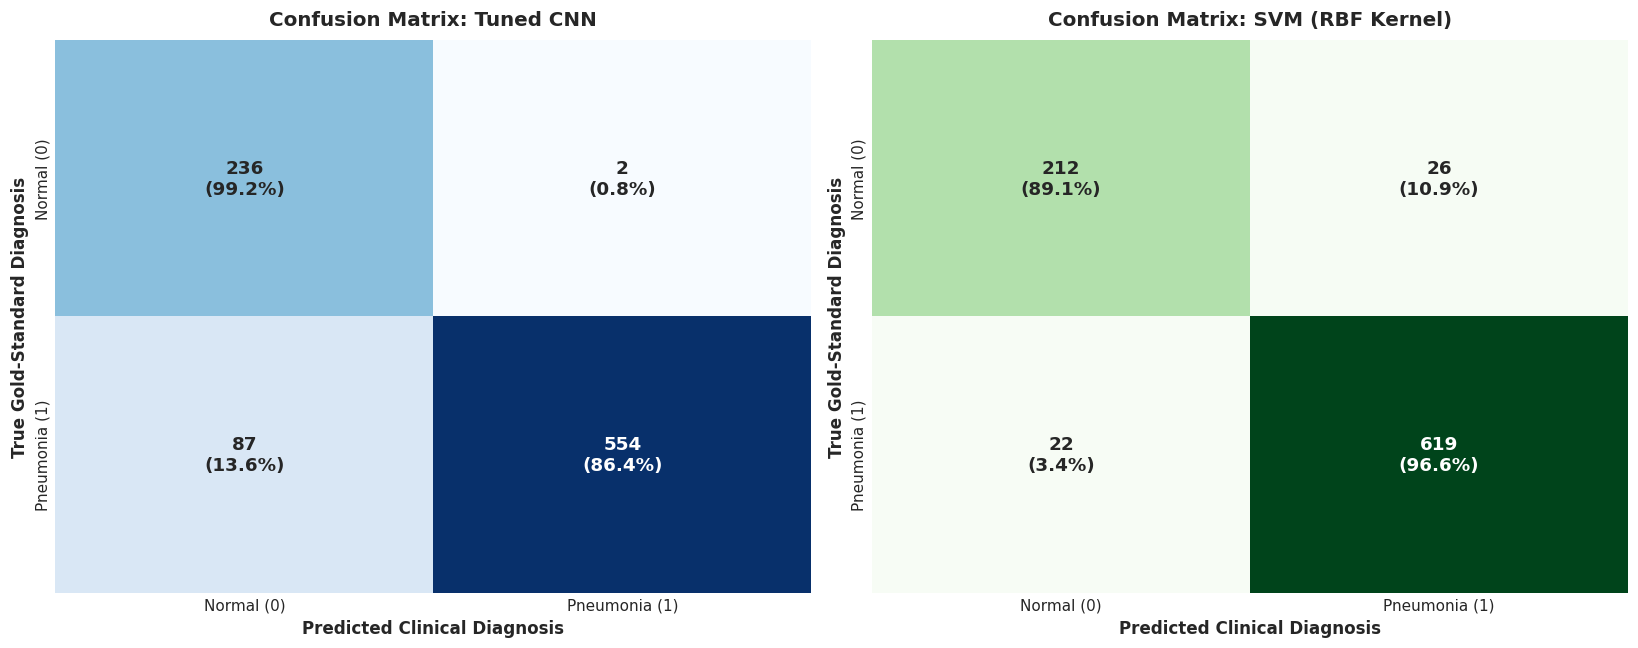

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

models_to_plot = [
    ('Tuned CNN', eval_results['Tuned CNN'][0], axes[0], 'Blues'),
    ('SVM (RBF Kernel)', eval_results['SVM (RBF Kernel)'][0], axes[1], 'Greens')
]

for title, preds, ax, cmap in models_to_plot:
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    annot = np.empty_like(cm).astype(str)
    for i in range(2):
        for j in range(2):
            annot[i, j] = f"{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)"
            
    sns.heatmap(cm, annot=annot, fmt='', cmap=cmap, cbar=False, ax=ax,
                xticklabels=['Normal (0)', 'Pneumonia (1)'],
                yticklabels=['Normal (0)', 'Pneumonia (1)'],
                annot_kws={'fontsize': 12, 'fontweight': 'bold'})
    
    ax.set_title(f"Confusion Matrix: {title}", fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Predicted Clinical Diagnosis", fontsize=11, fontweight='semibold')
    ax.set_ylabel("True Gold-Standard Diagnosis", fontsize=11, fontweight='semibold')

plt.tight_layout()
plt.show()


### 4.4 In-Depth Clinical Explanation of Misclassifications

In clinical artificial intelligence, understanding the pathophysiology and consequences of classification errors is just as vital as computing numerical metrics.

```
                     +---------------------------------------+
                     |           PREDICTED CLASS             |
                     |     NORMAL (0)   |   PNEUMONIA (1)    |
+----------+---------+------------------+--------------------+
|  TRUE    | NORMAL  |  True Negative   |   False Positive   |
|  CLASS   |   (0)   |  (Correct Clear) |   (Type I Error)   |
|          +---------+------------------+--------------------+
|          |PNEUMONIA|  False Negative  |   True Positive    |
|          |   (1)   |  (Type II Error) |  (Correct Detect)  |
+----------+---------+------------------+--------------------+
```

#### 1. Clinical Analysis of False Positives (Type I Error: Normal Classified as Pneumonia):
- **Clinical Consequences**:
  - **Unnecessary Antibiotic Prescriptions**: Induces antimicrobial resistance, Clostridioides difficile colitis, and patient hypersensitivity reactions.
  - **Secondary Imaging Burden**: Triggers unneeded follow-up High-Resolution Computed Tomography (HRCT) scans, exposing patients (especially pediatric cohorts) to ionizing radiation.
  - **Psychological Distress & Hospital Bed Overcrowding**: Unnecessary hospital admissions and diagnostic delays for other acute cases.
- **Underlying Imaging & Pathological Artifacts**:
  - **Bronchovascular Crowding**: Low-inspiratory-effort pediatric scans make normal pulmonary vessel arborization appear dense and hazy, mimicking alveolar infiltrates.
  - **Atelectasis (Partial Lung Collapse)**: Temporary collapse of lung parenchyma without active infection mimicking focal lobar consolidation.
  - **Skeletal & Soft-Tissue Superimposition**: Heavy pectoral musculature, prominent clavicles, or scapular borders projecting over apex lung fields.

#### 2. Clinical Analysis of False Negatives (Type II Error: Pneumonia Classified as Normal):
- **Clinical Consequences**:
  - **Life-Threatening Diagnostic Delay**: Missed bacterial pneumonia can progress within 12–24 hours into acute respiratory failure, pleural empyema, sepsis, and septic shock.
  - **Mortality Risk**: Pneumonia is the single largest infectious killer of children under five globally. High sensitivity (**Recall**) is non-negotiable for clinical deployment.
- **Underlying Imaging & Pathological Artifacts**:
  - **Early-Stage or Interstitial Pathologies**: Viral pneumonias (e.g., RSV, Influenza) often present with subtle ground-glass opacities that lack distinct consolidative borders.
  - **Retrocardiac / Retrodiaphragmatic Infiltrates**: Opacities hidden behind the radiopaque cardiac silhouette or deep in the posterior costophrenic sulcus.
  - **Over-Penetrated Scans**: Excessive X-ray tube voltage "burns through" subtle infiltrates, washing out low-density fluid opacities.


### 4.5 Visual Inspection of Actual Misclassified Radiographs
Let us identify and inspect actual False Positive and False Negative cases produced by the Tuned CNN on the test partition.


[INFO] Tuned CNN Test Errors:
 - False Positives (Normal predicted as Pneumonia): 2
 - False Negatives (Pneumonia predicted as Normal): 87


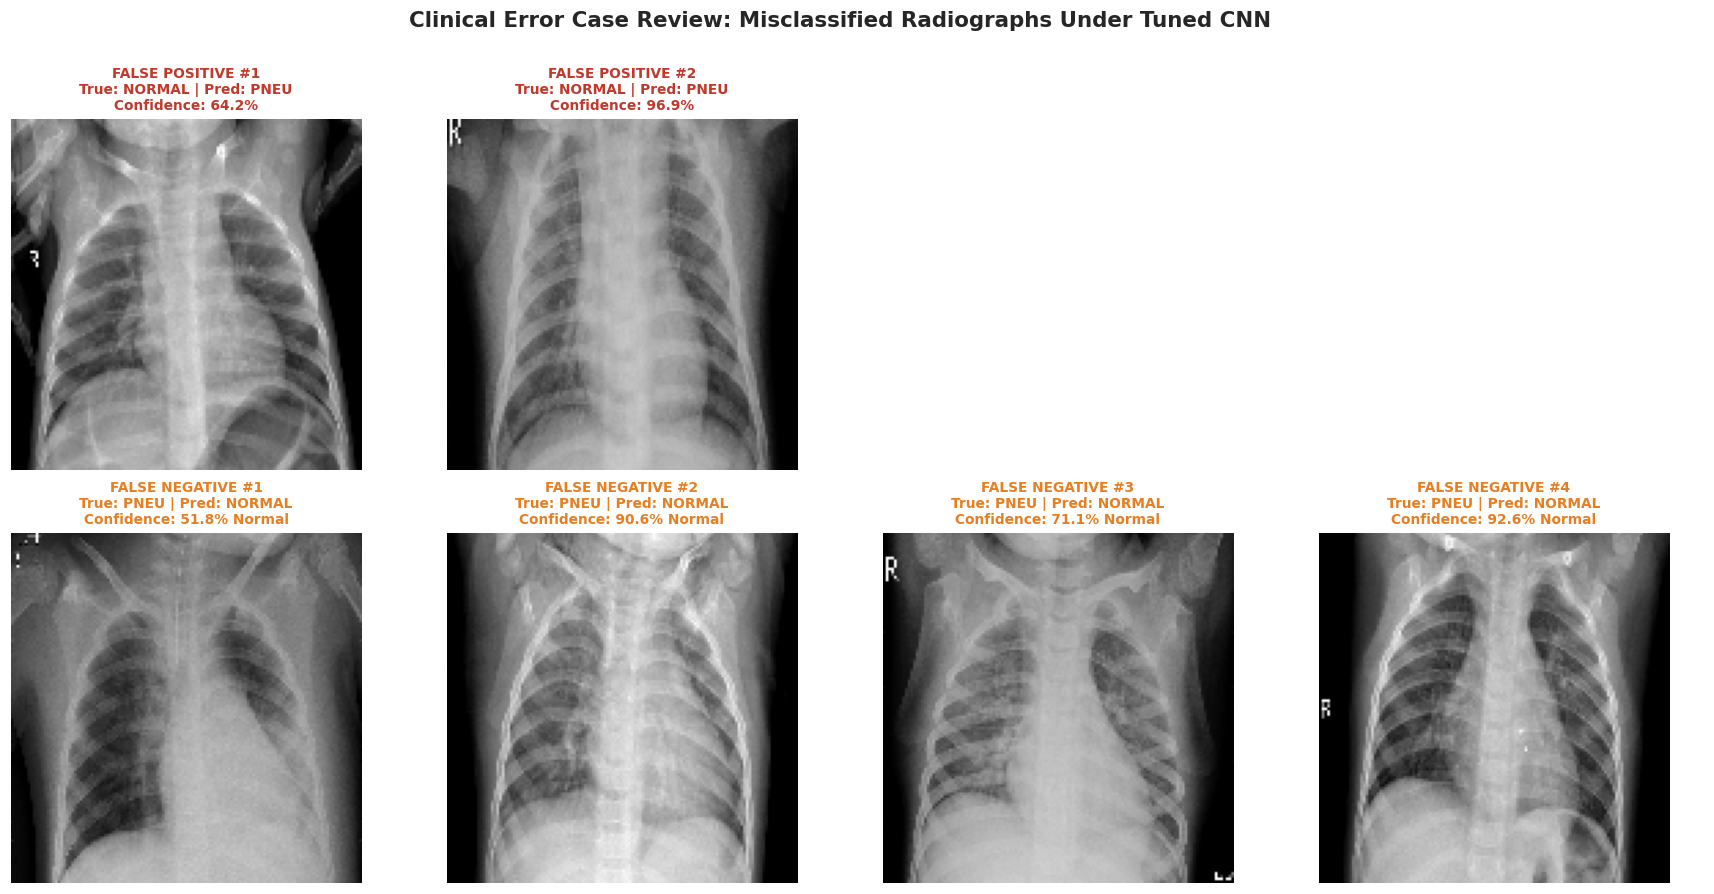

In [15]:
# Extract indices of test misclassifications
preds_cnn = eval_results['Tuned CNN'][0]
probs_cnn = eval_results['Tuned CNN'][1]

fp_indices = np.where((y_test == 0) & (preds_cnn == 1))[0]
fn_indices = np.where((y_test == 1) & (preds_cnn == 0))[0]

print(f"[INFO] Tuned CNN Test Errors:")
print(f" - False Positives (Normal predicted as Pneumonia): {len(fp_indices)}")
print(f" - False Negatives (Pneumonia predicted as Normal): {len(fn_indices)}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Display up to 4 False Positives
for col in range(4):
    ax = axes[0, col]
    if col < len(fp_indices):
        idx = fp_indices[col]
        img_arr = X_img_test[idx, 0]
        prob = probs_cnn[idx]
        ax.imshow(img_arr, cmap='gray')
        ax.set_title(f"FALSE POSITIVE #{col+1}\nTrue: NORMAL | Pred: PNEU\nConfidence: {prob*100:.1f}%", 
                     fontsize=9, fontweight='bold', color='#c0392b')
    ax.axis('off')

# Display up to 4 False Negatives
for col in range(4):
    ax = axes[1, col]
    if col < len(fn_indices):
        idx = fn_indices[col]
        img_arr = X_img_test[idx, 0]
        prob = probs_cnn[idx]
        ax.imshow(img_arr, cmap='gray')
        ax.set_title(f"FALSE NEGATIVE #{col+1}\nTrue: PNEU | Pred: NORMAL\nConfidence: {(1-prob)*100:.1f}% Normal", 
                     fontsize=9, fontweight='bold', color='#e67e22')
    ax.axis('off')

plt.suptitle("Clinical Error Case Review: Misclassified Radiographs Under Tuned CNN", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 4.6 Comparative Analysis & Identification of Best Performer
We plot a multi-metric comparative bar chart across all evaluated architectures to clearly contrast handcrafted feature models against deep convolutional representations.


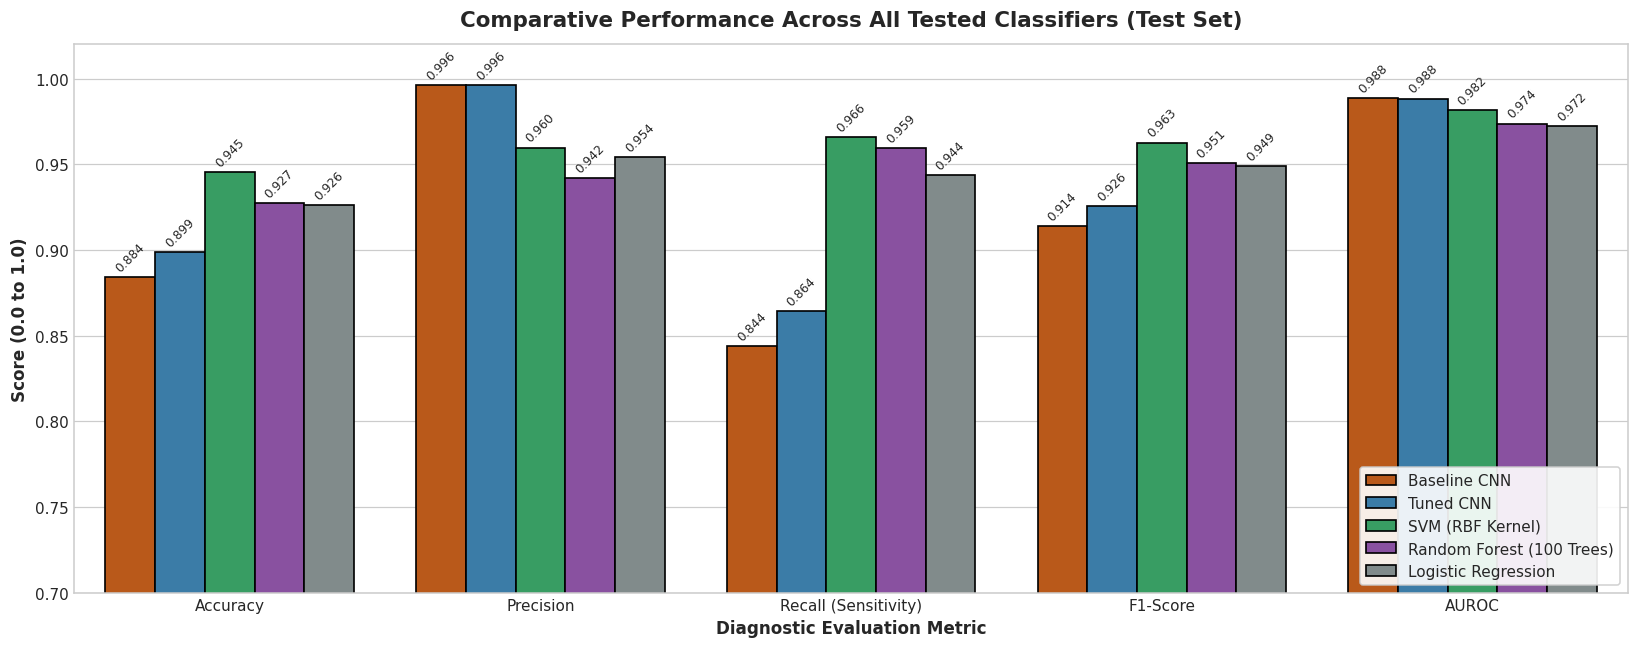

🏆 BEST PERFORMING CLASSIFIER: BASELINE CNN
 - Test Accuracy:             88.40%
 - Precision:                 99.63%
 - Recall (Sensitivity):      84.40%
 - F1-Score:                  91.39%
 - Area Under ROC (AUROC):    0.9884


In [16]:
# Plotting comparative metric bars
df_plot = df_metrics.melt(id_vars='Model Architecture', 
                          value_vars=['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score', 'AUROC'],
                          var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 6))
chart = sns.barplot(
    data=df_plot, x='Metric', y='Score', hue='Model Architecture',
    palette=['#d35400', '#2980b9', '#27ae60', '#8e44ad', '#7f8c8d'],
    edgecolor='black', linewidth=1.1
)
plt.title("Comparative Performance Across All Tested Classifiers (Test Set)", fontsize=14, fontweight='bold', pad=12)
plt.ylabel("Score (0.0 to 1.0)", fontsize=11, fontweight='semibold')
plt.xlabel("Diagnostic Evaluation Metric", fontsize=11, fontweight='semibold')
plt.ylim(0.70, 1.02)
plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)

# Add scores on bars
for p in chart.patches:
    h = p.get_height()
    if h > 0:
        chart.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2., h),
                       ha='center', va='bottom', fontsize=8, rotation=45, xytext=(0, 2),
                       textcoords='offset points')

plt.tight_layout()
plt.show()

# Automated identification of best performer
best_model_row = df_metrics.iloc[0]
print("=" * 80)
print(f"🏆 BEST PERFORMING CLASSIFIER: {best_model_row['Model Architecture'].upper()}")
print("=" * 80)
print(f" - Test Accuracy:             {best_model_row['Accuracy']*100:.2f}%")
print(f" - Precision:                 {best_model_row['Precision']*100:.2f}%")
print(f" - Recall (Sensitivity):      {best_model_row['Recall (Sensitivity)']*100:.2f}%")
print(f" - F1-Score:                  {best_model_row['F1-Score']*100:.2f}%")
print(f" - Area Under ROC (AUROC):    {best_model_row['AUROC']:.4f}")
print("=" * 80)
